# 高斯朴素贝叶斯分类

vip: -14.96, ord: -105.41


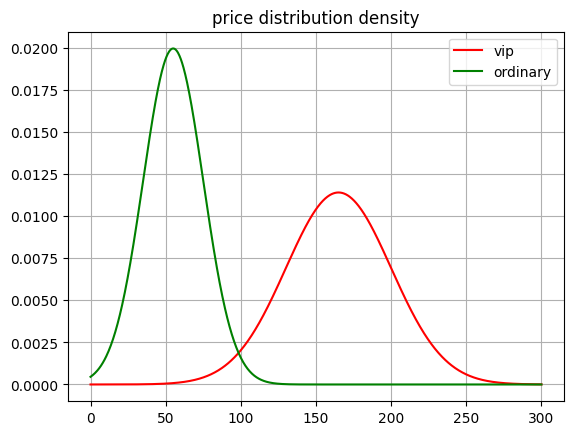

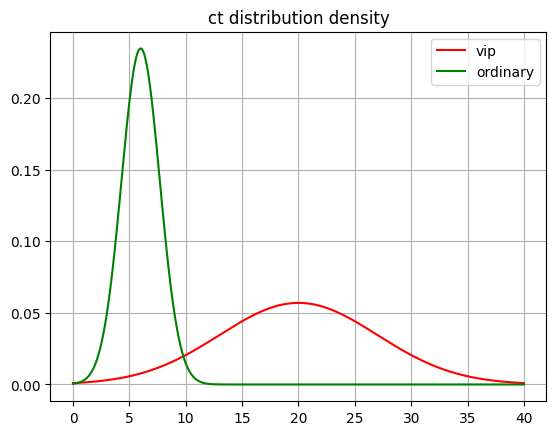

In [24]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

vip_prob = 0.3

vip_price_mu = 165
vip_price_sigma = 35

ord_price_mu = 55
ord_price_sigma = 20

vip_ct_mu = 20
vip_ct_sigma = 7

ord_ct_mu = 6
ord_ct_sigma = 1.7

def posterior(price, ct):
    vip_price_density = norm.pdf(price, vip_price_mu, vip_price_sigma)
    vip_ct_density = norm.pdf(ct, vip_ct_mu, vip_ct_sigma)

    ord_price_density = norm.pdf(price, ord_price_mu, ord_price_sigma)
    ord_ct_density = norm.pdf(ct, ord_ct_mu, ord_ct_sigma)

    # vip_val = vip_price_density * vip_ct_density * vip_prob
    # ord_val = ord_price_density * ord_ct_density * (1-vip_prob)
    vip_val = np.log(vip_price_density) + np.log(vip_ct_density) + np.log(vip_prob)
    ord_val = np.log(ord_price_density) + np.log(ord_ct_density) + np.log(1-vip_prob)

    return [vip_val, ord_val]



vipval, ordval = posterior(price=50, ct=30)
# print(f'vip: {np.log(vipval):.2f}, ord: {np.log(ordval):.2f}')
print(f'vip: {vipval:.2f}, ord: {ordval:.2f}')


x = np.linspace(0, 300, 1000)
pdf = norm.pdf(x, vip_price_mu, vip_price_sigma)
pdf2 = norm.pdf(x, ord_price_mu, ord_price_sigma)
plt.plot(x, pdf, label=f'vip', color='red')
plt.plot(x, pdf2, label=f'ordinary', color='green')
plt.title('price distribution density')
plt.legend()
plt.grid(True)
plt.show()

x = np.linspace(0, 40, 1000)
pdf = norm.pdf(x, vip_ct_mu, vip_ct_sigma)
pdf2 = norm.pdf(x, ord_ct_mu, ord_ct_sigma)
plt.plot(x, pdf, label=f'vip', color='red')
plt.plot(x, pdf2, label=f'ordinary', color='green')
plt.title('ct distribution density')
plt.legend()
plt.grid(True)
plt.show()